In [1]:
# 1. 导入模块、读取配置和路径
import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

_base = Path('/home/intern_fjq_2026').resolve()
_current = Path.cwd().resolve()
_candidates = [
    _base / 'Projects' / 'chinese-wwm-roberta',
    _base.parent / 'intern_fjq_2026' / 'Projects' / 'chinese-wwm-roberta',
    _current,
    _current.parent,
]
ROOT = next((path for path in _candidates if (path / 'src').is_dir()), None)
assert ROOT is not None, 'Repository root was not found'
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.activation_rank import (
    finalize_activation_rank_run,
    load_activation_rank_config,
    plot_rank_curves,
    plot_rank_heatmap,
    preflight_activation_rank,
    run_pilot_stage,
    run_rank_analysis_stage,
    run_rank_shards_stage,
    run_sample_stage,
    run_wo_mechanism_stage,
    validate_pilot_outputs,
    validate_rank_analysis_outputs,
    validate_wo_mechanism_outputs,
)

CONFIG_PATH = ROOT / 'configs' / 'activation_rank.yaml'
config = load_activation_rank_config(CONFIG_PATH)
RUN_DIR = Path(config['output']['run_directory']).expanduser().resolve()
display({'config': str(CONFIG_PATH), 'run_directory': str(RUN_DIR)})

{'config': '/home/intern_fjq_2026/Projects/chinese-wwm-roberta/configs/activation_rank.yaml',
 'run_directory': '/home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/checkpoint_activation_rank/runs/financial_reports_v2'}

In [2]:
# 2. 服务器、GPU、磁盘、checkpoint与文本preflight
preflight = preflight_activation_rank(config)
display(preflight)
assert preflight['status'].eq('ok').all(), preflight

,check,status,detail
0,text,ok,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
1,checkpoint,ok,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
2,tokenizer,ok,/home/intern_fjq_2026/Projects/chinese-wwm-rob...
3,disk_budget,ok,"{""estimated_peak"": 6442450944, ""free"": 5746040..."
4,cpu_runtime,ok,"{""configured_threads"": 8, ""effective_threads"":..."
5,gpu_runtime,ok,"{""requested_device"": ""cuda:1"", ""cuda"": true, ""..."


In [3]:
# 3. 构建或严格复用sample manifest
sample_dir = run_sample_stage(config)
sample_manifest = pd.read_parquet(sample_dir / 'sample_manifest.parquet')
display(sample_manifest.head())
display(sample_manifest.groupby('shard')['token_count'].agg(['count', 'sum']))

,sample_row,source_row,report_id,text_sha256,stable_order,shard,token_count,is_unique_text
0,0,346841,392db3cbaf986062aef667b53d6994da444f439fd98453...,468d24aa18e6dab2482f63abe663851ef7b60279373433...,8991769536629,5,4,True
1,1,434587,c177b5ba77aa9a09b3c23a9922ffde040348deafe9d8ea...,0d1f506e308adb49f8a189f231bbe2754cfa821e4ee3bc...,38137858979464,0,510,True
2,2,218975,aa1326815aa7290a446a0652d787aa1dffc90f590c8d4b...,7074ed77bd1921175bfdaf101fe72a978b1e2cb02eb6a4...,40860073821757,5,4,True
3,3,845838,aaf9db3452ece97636747d2fbf304041e7da5732e67d0b...,967792222fe09f4cf0c194313fa823b965d01f8afbe66e...,58351295589966,6,510,True
4,4,987663,f18291e784eb476780fa2ab47c35f60ee5c9c5f6a188b4...,e7f1fbe3bb6af2bc1545ac1a06ce2ca04488fd030f03f2...,66113139498634,2,510,True


,count,sum
shard,,
0,3499,1250032
1,3374,1250126
2,3424,1250242
3,3473,1250062
4,3401,1250460
5,3399,1250149
6,3381,1250012
7,3463,1250496


In [5]:
# 4. hooks、精度、batch size与吞吐pilot
pilot_dir = run_pilot_stage(config)
pilot_manifest = validate_pilot_outputs(pilot_dir)
display(pd.Series(pilot_manifest))
display(pd.read_parquet(pilot_dir / 'batch_benchmark.parquet'))
display(pd.read_parquet(pilot_dir / 'precision_metrics.parquet'))

/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


schema_version                                        activation_rank_pilot_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             f143f1070d1e83a5958f43c1b4b28f9f8ffed0688f47d8...
config_sha256                  53500234d64b9ab4bda96ccc11b90d08ae992832c4b569...
max_length                                                                   512
git_commit                              bc987d4598a4038384255d55a73b87b83b3a13b9
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                a0e793adee21b4dcaf56bab0412c1cfd75c76d0bb865e6...
created_at                                                   2026-09-02T08:49:17
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
pilot_valid_tokens          

,batch_size,status,peak_memory_bytes,total_memory_bytes,headroom_fraction,checksum,rows,valid_tokens,batches,seconds,valid_tokens_per_second,padding_ratio
0,64,ok,2741471232,85043904512,0.967764,5.042122e+05,128,44528,3,1.431744,31100.532385,0.032743
1,128,ok,5065426944,85043904512,0.940438,1.014196e+06,256,89484,3,1.938374,46164.462184,0.032904
2,256,ok,9710602240,85043904512,0.885817,2.041665e+06,512,179221,3,3.778740,47428.776809,0.033922
3,512,ok,19001609216,85043904512,0.776567,4.106788e+06,1024,362221,3,7.582907,47768.093850,0.033287


,dtype,rows,valid_tokens,batches,seconds,valid_tokens_per_second,padding_ratio,peak_memory_bytes,maximum_normalized_erank_difference,maximum_k99_difference,maximum_relative_spectrum_difference_above_1pct,passed
0,float32,1410,502928,3,10.199924,49307.034378,0.033218,19484496384,0.000000,0,0.000000,True
1,float16,1410,502928,3,5.070512,99186.835324,0.033218,9988630016,0.000165,1,0.002066,True
2,bfloat16,1410,502928,3,5.019020,100204.425529,0.033218,9988630016,0.001673,2,0.023174,False


In [6]:
# 5. 运行缺失的rank shards；已验证分片自动跳过
# kernel重启或某一shard失败后，只需重跑cell 1与本cell。
try:
    moments_dir = run_rank_shards_stage(config)
except RuntimeError:
    audit_candidates = [RUN_DIR / 'moments' / 'norm_audit_5m.parquet', RUN_DIR / 'moments' / 'norm_audit.parquet']
    for audit_path in audit_candidates:
        if audit_path.is_file():
            display(pd.read_parquet(audit_path).sort_values(['blocking', 'position_passed', 'population', 'site'], ascending=[False, True, True, True]))
    raise
moments_manifest = json.loads((moments_dir / 'manifest.json').read_text(encoding='utf-8'))
display(pd.Series(moments_manifest))
display(pd.DataFrame(moments_manifest['norm_audit']['failed_blocking_positions']))
norm_audit = pd.read_parquet(moments_dir / 'norm_audit.parquet')
display(norm_audit.sort_values(['blocking', 'position_passed', 'population', 'site'], ascending=[False, True, True, True]))

schema_version                                        activation_rank_shard_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             f143f1070d1e83a5958f43c1b4b28f9f8ffed0688f47d8...
config_sha256                  53500234d64b9ab4bda96ccc11b90d08ae992832c4b569...
max_length                                                                   512
git_commit                              bc987d4598a4038384255d55a73b87b83b3a13b9
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                a0e793adee21b4dcaf56bab0412c1cfd75c76d0bb865e6...
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
selected_batch_size                                                          512
norm_thresholds_sha256      

""


,population,site,blocking,compute_dtype,dtype_epsilon,pilot_count,main_count,pilot_mean,main_mean,pilot_std,...,relative_norm_std_shift,filtered_count,filtered_fraction,mean_tolerance,std_tolerance,filtered_fraction_tolerance,mean_passed,std_passed,filtered_passed,position_passed
25,token,attention_output_01,True,float16,0.000977,502928,10001579,10.145392,10.148972,1.458205,...,0.002090,0,0.000000e+00,0.01,0.03,0.01,True,True,True,True
26,token,attention_output_02,True,float16,0.000977,502928,10001579,10.490377,10.486995,1.309231,...,0.000844,0,0.000000e+00,0.01,0.03,0.01,True,True,True,True
27,token,attention_output_03,True,float16,0.000977,502928,10001579,8.784603,8.781712,1.466393,...,0.001030,195,1.949692e-05,0.01,0.03,0.01,True,True,True,True
28,token,attention_output_04,True,float16,0.000977,502928,10001579,9.084502,9.083065,1.307857,...,0.000581,4,3.999368e-07,0.01,0.03,0.01,True,True,True,True
29,token,attention_output_05,True,float16,0.000977,502928,10001579,7.976680,7.972199,1.667328,...,0.000628,1552,1.551755e-04,0.01,0.03,0.01,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,cls,z_05,False,float16,0.000977,1410,27414,3.046209,3.038715,0.256379,...,0.029791,0,0.000000e+00,0.01,0.03,0.01,True,True,True,True
67,cls,z_06,False,float16,0.000977,1410,27414,2.387933,2.387770,0.064541,...,0.021144,0,0.000000e+00,0.01,0.03,0.01,True,True,True,True
68,cls,z_07,False,float16,0.000977,1410,27414,2.139839,2.135807,0.109907,...,0.025818,0,0.000000e+00,0.01,0.03,0.01,True,True,True,True
69,cls,z_08,False,float16,0.000977,1410,27414,1.935538,1.941724,0.185342,...,0.013969,0,0.000000e+00,0.01,0.03,0.01,True,True,True,True


In [7]:
# 6. 合并moments、FP64特征分解与稳定性/坍缩分析
analysis_dir = run_rank_analysis_stage(config)
display(pd.Series(validate_rank_analysis_outputs(analysis_dir)))
rank_metrics = pd.read_parquet(analysis_dir / 'rank_metrics.parquet')
compression_metrics = pd.read_parquet(analysis_dir / 'compression_metrics.parquet')
display(rank_metrics)
display(compression_metrics)

schema_version                                     activation_rank_analysis_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             f143f1070d1e83a5958f43c1b4b28f9f8ffed0688f47d8...
config_sha256                  53500234d64b9ab4bda96ccc11b90d08ae992832c4b569...
max_length                                                                   512
git_commit                              bc987d4598a4038384255d55a73b87b83b3a13b9
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                a0e793adee21b4dcaf56bab0412c1cfd75c76d0bb865e6...
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
selected_batch_size                                                          512
norm_thresholds_sha256      

,stream,site,kind,layer,count,effective_rank,normalized_effective_rank,stable_rank,k90_variance,k95_variance,k99_variance,directions_above_1pct_max,dimension
0,token_natural_filtered,residual_00,residual,0,10001579,596.498733,0.776691,45.388280,343,456,635,765,768
1,token_natural_filtered,residual_01,residual,1,10001579,593.941689,0.773362,35.890480,331,448,640,767,768
2,token_natural_filtered,residual_02,residual,2,10001579,608.881733,0.792815,28.284154,354,477,664,767,768
3,token_natural_filtered,residual_03,residual,3,10001579,618.536724,0.805386,26.222119,373,499,679,767,768
4,token_natural_filtered,residual_04,residual,4,10001579,613.473939,0.798794,25.142447,367,497,681,767,768
...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,token_unique_filtered,mlp_output_08,mlp_output,8,9979379,639.058750,0.832108,28.584081,405,520,684,768,768
241,token_unique_filtered,mlp_output_09,mlp_output,9,9979298,635.548671,0.827537,24.386715,399,516,682,768,768
242,token_unique_filtered,mlp_output_10,mlp_output,10,9979785,621.980650,0.809871,16.408499,374,495,674,768,768
243,token_unique_filtered,mlp_output_11,mlp_output,11,9979719,622.623741,0.810708,21.421042,381,500,673,768,768


,layer,ratio_erank_o_to_z,ratio_erank_o_to_z_ci_lower,ratio_erank_o_to_z_ci_upper,ratio_erank_o_to_mlp,ratio_erank_o_to_mlp_ci_lower,ratio_erank_o_to_mlp_ci_upper,ratio_erank_o_to_residual,ratio_erank_o_to_residual_ci_lower,ratio_erank_o_to_residual_ci_upper,evidence
0,1,0.696739,0.696573,0.696889,0.637088,0.636671,0.637442,0.633762,0.633300,0.634163,clear_collapse
1,2,0.737574,0.737494,0.737650,0.624082,0.623943,0.624210,0.634853,0.634632,0.635059,clear_collapse
2,3,0.752953,0.752876,0.753019,0.689520,0.689409,0.689639,0.705694,0.705552,0.705830,clear_collapse
3,4,0.744842,0.744737,0.744954,0.691791,0.691685,0.691901,0.712575,0.712352,0.712811,clear_collapse
4,5,0.780788,0.780692,0.780883,0.695512,0.695304,0.695735,0.710785,0.710583,0.710981,clear_collapse
5,6,0.770149,0.770099,0.770197,0.737244,0.737175,0.737333,0.766442,0.766315,0.766573,clear_collapse
6,7,0.779284,0.779251,0.779320,0.718510,0.718300,0.718713,0.747865,0.747701,0.748023,clear_collapse
7,8,0.833102,0.833005,0.833186,0.734125,0.733950,0.734283,0.764416,0.764291,0.764548,clear_collapse
8,9,0.777680,0.777595,0.777772,0.747352,0.747216,0.747521,0.769243,0.769088,0.769429,clear_collapse
9,10,0.793312,0.793058,0.793553,0.738282,0.737574,0.738902,0.742259,0.741556,0.742888,clear_collapse


In [8]:
# 7. W^O协方差恒等式、方向分解与反事实机制分析
mechanism_dir = run_wo_mechanism_stage(config)
display(pd.Series(validate_wo_mechanism_outputs(mechanism_dir)))
display(pd.read_parquet(mechanism_dir / 'wo_summary.parquet'))
display(pd.read_parquet(mechanism_dir / 'wo_mechanism.parquet').head(24))

schema_version                                 activation_rank_wo_mechanism_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             f143f1070d1e83a5958f43c1b4b28f9f8ffed0688f47d8...
config_sha256                  53500234d64b9ab4bda96ccc11b90d08ae992832c4b569...
max_length                                                                   512
git_commit                              bc987d4598a4038384255d55a73b87b83b3a13b9
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                a0e793adee21b4dcaf56bab0412c1cfd75c76d0bb865e6...
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
selected_batch_size                                                          512
norm_thresholds_sha256      

,layer,covariance_relative_frobenius_error,observed_learned_wo_effective_rank,observed_learned_wo_normalized_effective_rank,observed_learned_wo_k99_variance,polar_orthogonal_scaled_effective_rank,polar_orthogonal_scaled_normalized_effective_rank,polar_orthogonal_scaled_k99_variance,random_orthogonal_scaled_effective_rank,random_orthogonal_scaled_normalized_effective_rank,random_orthogonal_scaled_k99_variance,wo_only_isotropic_input_effective_rank,wo_only_isotropic_input_normalized_effective_rank,wo_only_isotropic_input_k99_variance,covariance_identity_tolerance,covariance_identity_passed
0,1,0.000216,376.563783,0.490317,363,540.582138,0.703883,571,540.582138,0.703883,571,574.900814,0.748569,562,0.005,True
1,2,0.000253,386.682899,0.503493,363,524.369522,0.682773,538,524.369522,0.682773,538,571.279495,0.743854,554,0.005,True
2,3,0.000261,436.549340,0.568424,431,579.805343,0.754955,617,579.805343,0.754955,617,582.022475,0.757842,557,0.005,True
3,4,0.000265,437.241383,0.569325,430,587.072931,0.764418,632,587.072931,0.764418,632,572.478791,0.745415,554,0.005,True
4,5,0.000304,435.695437,0.567312,428,558.132864,0.726735,609,558.132864,0.726735,609,573.124933,0.746256,551,0.005,True
5,6,0.000279,468.269372,0.609726,464,608.067998,0.791755,673,608.067998,0.791755,673,581.801080,0.757553,555,0.005,True
6,7,0.000265,459.558742,0.598384,456,589.706768,0.767847,634,589.706768,0.767847,634,596.939284,0.777265,566,0.005,True
7,8,0.000343,471.886559,0.614436,475,564.151006,0.734572,611,564.151006,0.734572,611,597.845947,0.778445,570,0.005,True
8,9,0.000281,475.088599,0.618605,483,611.117138,0.795725,682,611.117138,0.795725,682,600.116044,0.781401,576,0.005,True
9,10,0.000284,459.566002,0.598393,469,579.358224,0.754373,666,579.358224,0.754373,666,601.153587,0.782752,573,0.005,True


,layer,component,attention_output_eigenvalue,z_directional_variance,wo_scale_squared,factor_product
0,1,1,5.201999,1.373344,3.787833,5.202000
1,1,2,3.323629,0.811079,4.097830,3.323662
2,1,3,2.465813,0.670848,3.675646,2.465800
3,1,4,2.187486,0.693173,3.155753,2.187483
4,1,5,2.035882,0.617285,3.298157,2.035902
5,1,6,1.744595,0.457558,3.812909,1.744625
6,1,7,1.508239,0.454479,3.318661,1.508261
7,1,8,1.480698,0.408965,3.620657,1.480724
8,1,9,1.359016,0.381025,3.566752,1.359023
9,1,10,1.327363,0.385152,3.446330,1.327361


schema_version                                          activation_rank_run_v2.0
checkpoint_sha256              b6de21972c150139d0407b8e8e92bed3db9f23f92a1c70...
tokenizer_sha256               53b05407adaa567cf2cb7b57a8d05b9ab399cbd40af55d...
text_source_sha256             f143f1070d1e83a5958f43c1b4b28f9f8ffed0688f47d8...
config_sha256                  53500234d64b9ab4bda96ccc11b90d08ae992832c4b569...
max_length                                                                   512
git_commit                              bc987d4598a4038384255d55a73b87b83b3a13b9
activation_rank_code_sha256    b0a428a100907afa6b83344ead27eefc7c8034c4a2bb87...
run_fingerprint                a0e793adee21b4dcaf56bab0412c1cfd75c76d0bb865e6...
selected_compute_dtype                                                   float16
norm_calibration_dtype                                                   float16
selected_batch_size                                                          512
norm_thresholds_sha256      

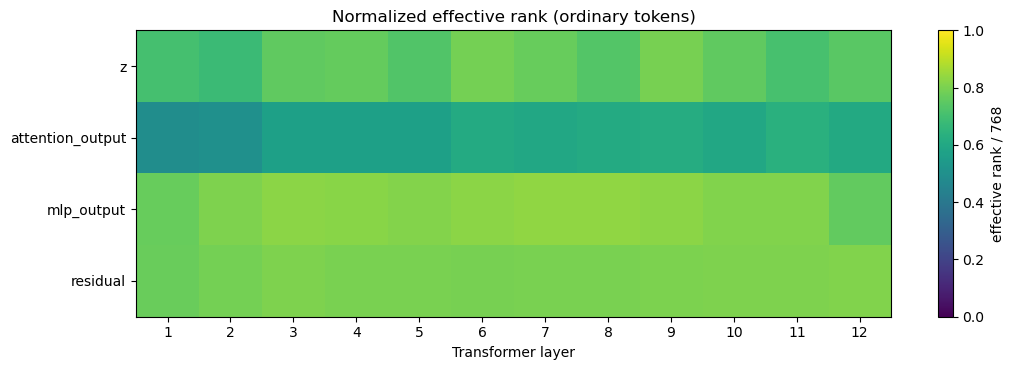

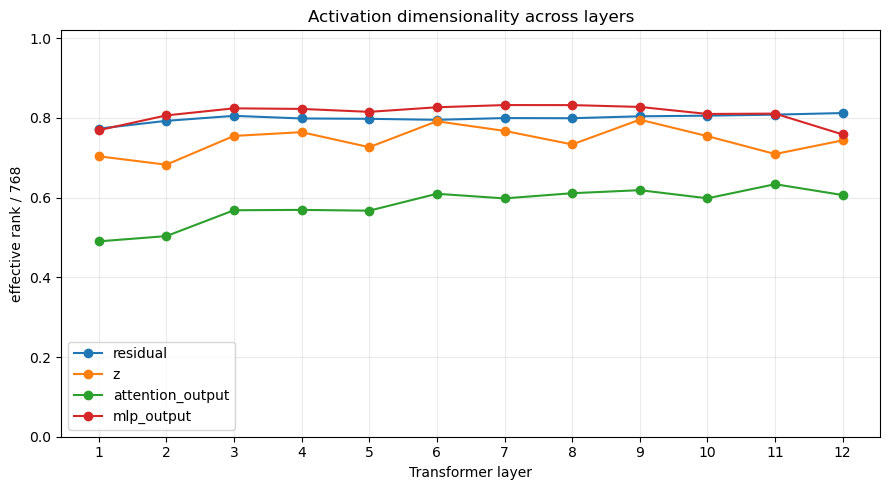

,layer,ratio_erank_o_to_z,ratio_erank_o_to_z_ci_lower,ratio_erank_o_to_z_ci_upper,ratio_erank_o_to_mlp,ratio_erank_o_to_mlp_ci_lower,ratio_erank_o_to_mlp_ci_upper,ratio_erank_o_to_residual,ratio_erank_o_to_residual_ci_lower,ratio_erank_o_to_residual_ci_upper,evidence
0,1,0.696739,0.696573,0.696889,0.637088,0.636671,0.637442,0.633762,0.633300,0.634163,clear_collapse
1,2,0.737574,0.737494,0.737650,0.624082,0.623943,0.624210,0.634853,0.634632,0.635059,clear_collapse
2,3,0.752953,0.752876,0.753019,0.689520,0.689409,0.689639,0.705694,0.705552,0.705830,clear_collapse
3,4,0.744842,0.744737,0.744954,0.691791,0.691685,0.691901,0.712575,0.712352,0.712811,clear_collapse
4,5,0.780788,0.780692,0.780883,0.695512,0.695304,0.695735,0.710785,0.710583,0.710981,clear_collapse
5,6,0.770149,0.770099,0.770197,0.737244,0.737175,0.737333,0.766442,0.766315,0.766573,clear_collapse
6,7,0.779284,0.779251,0.779320,0.718510,0.718300,0.718713,0.747865,0.747701,0.748023,clear_collapse
7,8,0.833102,0.833005,0.833186,0.734125,0.733950,0.734283,0.764416,0.764291,0.764548,clear_collapse
8,9,0.777680,0.777595,0.777772,0.747352,0.747216,0.747521,0.769243,0.769088,0.769429,clear_collapse
9,10,0.793312,0.793058,0.793553,0.738282,0.737574,0.738902,0.742259,0.741556,0.742888,clear_collapse


In [9]:
# 8. 图表、结论表与最终run manifest
completed_dir = finalize_activation_rank_run(config)
final_manifest = json.loads((completed_dir / 'manifest.json').read_text(encoding='utf-8'))
display(pd.Series(final_manifest))
display(plot_rank_heatmap(completed_dir / 'analysis'))
display(plot_rank_curves(completed_dir / 'analysis'))
display(pd.read_parquet(completed_dir / 'compression_metrics.parquet'))

,effective_rank,normalized_erank,k90,k95,k99,dirs_above_1pct,dimension
kind,,,,,,,
attention_output,446.4,0.6,198.6,279.8,442.9,655.2,768
mlp_output,623.2,0.8,378.7,495.1,668.0,763.9,768
residual,614.0,0.8,367.2,497.9,680.9,767.0,768
z,571.5,0.7,307.4,427.3,621.6,767.8,768


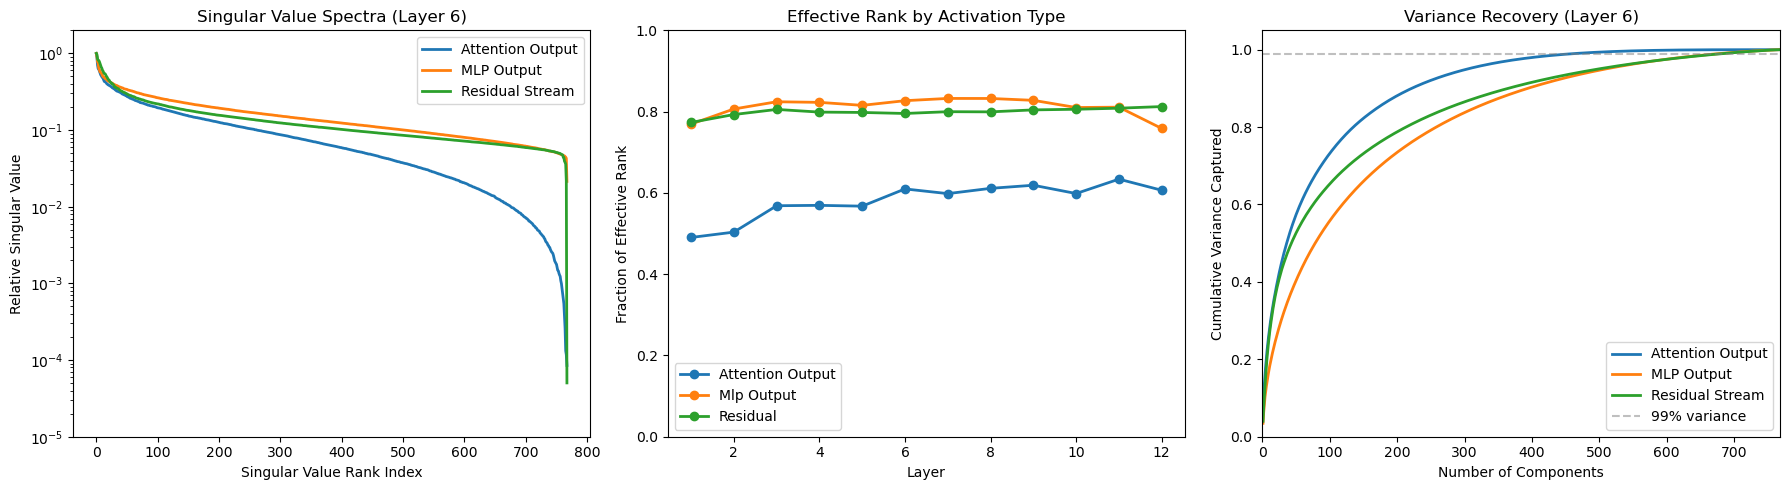


关键数值 (Layer 6):
  Attention Output    : dirs>1%=676/768 (88.0%), 99% var in 464/768 (60.4%)
  MLP Output          : dirs>1%=768/768 (100.0%), 99% var in 679/768 (88.4%)
  Residual Stream     : dirs>1%=767/768 (99.9%), 99% var in 684/768 (89.1%)


In [9]:
# 9. 谱衰减与有效维度对比 — 复现论文 Figure 3a
# 从已有 rank_metrics + subspaces 提取指标: attention_output vs MLP vs residual
import numpy as np
import matplotlib.pyplot as plt

try:
    completed_dir
except NameError:
    completed_dir = RUN_DIR

subspaces = np.load(completed_dir / 'analysis' / 'subspaces.npz', allow_pickle=False)
rank_metrics_full = pd.read_parquet(completed_dir / 'analysis' / 'rank_metrics.parquet')
rm = rank_metrics_full[rank_metrics_full['stream'] == 'token_natural_filtered'].copy()
rm_layers = rm[rm['layer'] > 0]

summary = rm_layers.groupby('kind').agg(
    effective_rank=('effective_rank', 'mean'),
    normalized_erank=('normalized_effective_rank', 'mean'),
    k90=('k90_variance', 'mean'),
    k95=('k95_variance', 'mean'),
    k99=('k99_variance', 'mean'),
    dirs_above_1pct=('directions_above_1pct_max', 'mean'),
    dimension=('dimension', 'first'),
).round(1)
display(summary)

layer = 6
sites = {
    'Attention Output': f'token_natural_filtered__attention_output_{layer:02d}',
    'MLP Output': f'token_natural_filtered__mlp_output_{layer:02d}',
    'Residual Stream': f'token_natural_filtered__residual_{layer:02d}',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 左: 奇异值谱 (Figure 3a)
ax = axes[0]
for label, prefix in sites.items():
    eigvals = subspaces[f'{prefix}__eigenvalues']
    sv = np.sqrt(np.maximum(eigvals, 0))
    rel_sv = sv / sv.max()
    ax.semilogy(range(len(rel_sv)), rel_sv, label=label, linewidth=2)
ax.set_xlabel('Singular Value Rank Index')
ax.set_ylabel('Relative Singular Value')
ax.set_title(f'Singular Value Spectra (Layer {layer})')
ax.legend()
ax.set_ylim(1e-5, 2)

# 中: 各层有效秩
ax = axes[1]
colors = {'attention_output': 'tab:blue', 'mlp_output': 'tab:orange', 'residual': 'tab:green'}
for kind in ['attention_output', 'mlp_output', 'residual']:
    sub_df = rm_layers[rm_layers['kind'] == kind].sort_values('layer')
    ax.plot(sub_df['layer'], sub_df['normalized_effective_rank'], 'o-',
            label=kind.replace('_', ' ').title(), color=colors[kind], linewidth=2)
ax.set_xlabel('Layer')
ax.set_ylabel('Fraction of Effective Rank')
ax.set_title('Effective Rank by Activation Type')
ax.legend()
ax.set_ylim(0, 1)

# 右: 累积方差恢复
ax = axes[2]
for label, prefix in sites.items():
    eigvals = np.maximum(subspaces[f'{prefix}__eigenvalues'], 0)
    cum = np.cumsum(eigvals) / eigvals.sum()
    ax.plot(range(1, len(cum) + 1), cum, label=label, linewidth=2)
ax.axhline(y=0.99, color='gray', linestyle='--', alpha=0.5, label='99% variance')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Variance Captured')
ax.set_title(f'Variance Recovery (Layer {layer})')
ax.legend()
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 768)

plt.tight_layout()
plt.show()

print(f'\n关键数值 (Layer {layer}):')
for label, prefix in sites.items():
    eigvals = np.maximum(subspaces[f'{prefix}__eigenvalues'], 0)
    sv = np.sqrt(eigvals)
    n_above_1pct = int((sv > 0.01 * sv.max()).sum())
    cum = np.cumsum(eigvals) / eigvals.sum()
    n_99 = int(np.searchsorted(cum, 0.99) + 1)
    dim = len(eigvals)
    print(f'  {label:20s}: dirs>1%={n_above_1pct}/{dim} ({100*n_above_1pct/dim:.1f}%), '
          f'99% var in {n_99}/{dim} ({100*n_99/dim:.1f}%)')

{'output': '/home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/checkpoint_activation_rank/runs/financial_reports_v2/extensions/loss_recovery_per_layer_cls_v1',
 'loss_semantics': 'cls_representation_distance__per_layer',
 'intervention_scope': 'per_layer_single_site',
 'layers': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 'kinds': ['attention_output'],
 'evaluation_reports': 256,
 'batch_size': 256,
 'pca_sample_report_overlap': 0,
 'pca_sample_text_hash_overlap': 0}

,site,kind,layer,status,distance_original,distance_zero,ablation_delta,denominator_bootstrap_se,denominator_signal_to_noise,sustained_recovery_threshold,n_sustained_recovery,full_projection_absolute_difference,full_projection_tolerance,full_projection_passed
0,attention_output_01,attention_output,1,identifiable,0.0,21.349231,21.349231,0.589601,36.209644,0.99,384,0.0,0.001,True
1,attention_output_02,attention_output,2,identifiable,0.0,11.802683,11.802683,0.326598,36.138310,0.99,512,0.0,0.001,True
2,attention_output_03,attention_output,3,identifiable,0.0,5.885376,5.885376,0.154479,38.098284,0.99,512,0.0,0.001,True
3,attention_output_04,attention_output,4,identifiable,0.0,8.627979,8.627979,0.337107,25.594164,0.99,512,0.0,0.001,True
4,attention_output_05,attention_output,5,identifiable,0.0,15.193574,15.193574,0.761324,19.956770,0.99,512,0.0,0.001,True
5,attention_output_06,attention_output,6,identifiable,0.0,12.354726,12.354726,0.380785,32.445447,0.99,640,0.0,0.001,True
6,attention_output_07,attention_output,7,identifiable,0.0,12.078010,12.078010,0.269714,44.780779,0.99,512,0.0,0.001,True
7,attention_output_08,attention_output,8,identifiable,0.0,15.201727,15.201727,0.321842,47.233521,0.99,640,0.0,0.001,True
8,attention_output_09,attention_output,9,identifiable,0.0,28.891186,28.891186,0.841886,34.317212,0.99,512,0.0,0.001,True
9,attention_output_10,attention_output,10,identifiable,0.0,37.531334,37.531334,1.718492,21.839696,0.99,512,0.0,0.001,True


,site,layer,n_components,distance_zero,distance_projected,status,recovery_fraction,recovery_ci_lower,recovery_ci_upper
0,attention_output_01,1,0,21.349231,21.349231,identifiable,0.000000,0.000000,0.000000
3,attention_output_01,1,64,21.349231,2.007492,identifiable,0.905969,0.896068,0.914305
4,attention_output_01,1,128,21.349231,1.263713,identifiable,0.940808,0.936742,0.944947
6,attention_output_01,1,256,21.349231,0.523909,identifiable,0.975460,0.973614,0.977232
7,attention_output_01,1,384,21.349231,0.146243,identifiable,0.993150,0.992501,0.993719
...,...,...,...,...,...,...,...,...,...
147,attention_output_12,12,128,225.585530,41.300040,identifiable,0.816921,0.798954,0.832733
149,attention_output_12,12,256,225.585530,20.287315,identifiable,0.910068,0.899580,0.919143
150,attention_output_12,12,384,225.585530,8.445410,identifiable,0.962562,0.957944,0.966462
151,attention_output_12,12,512,225.585530,2.321576,identifiable,0.989709,0.988384,0.990817


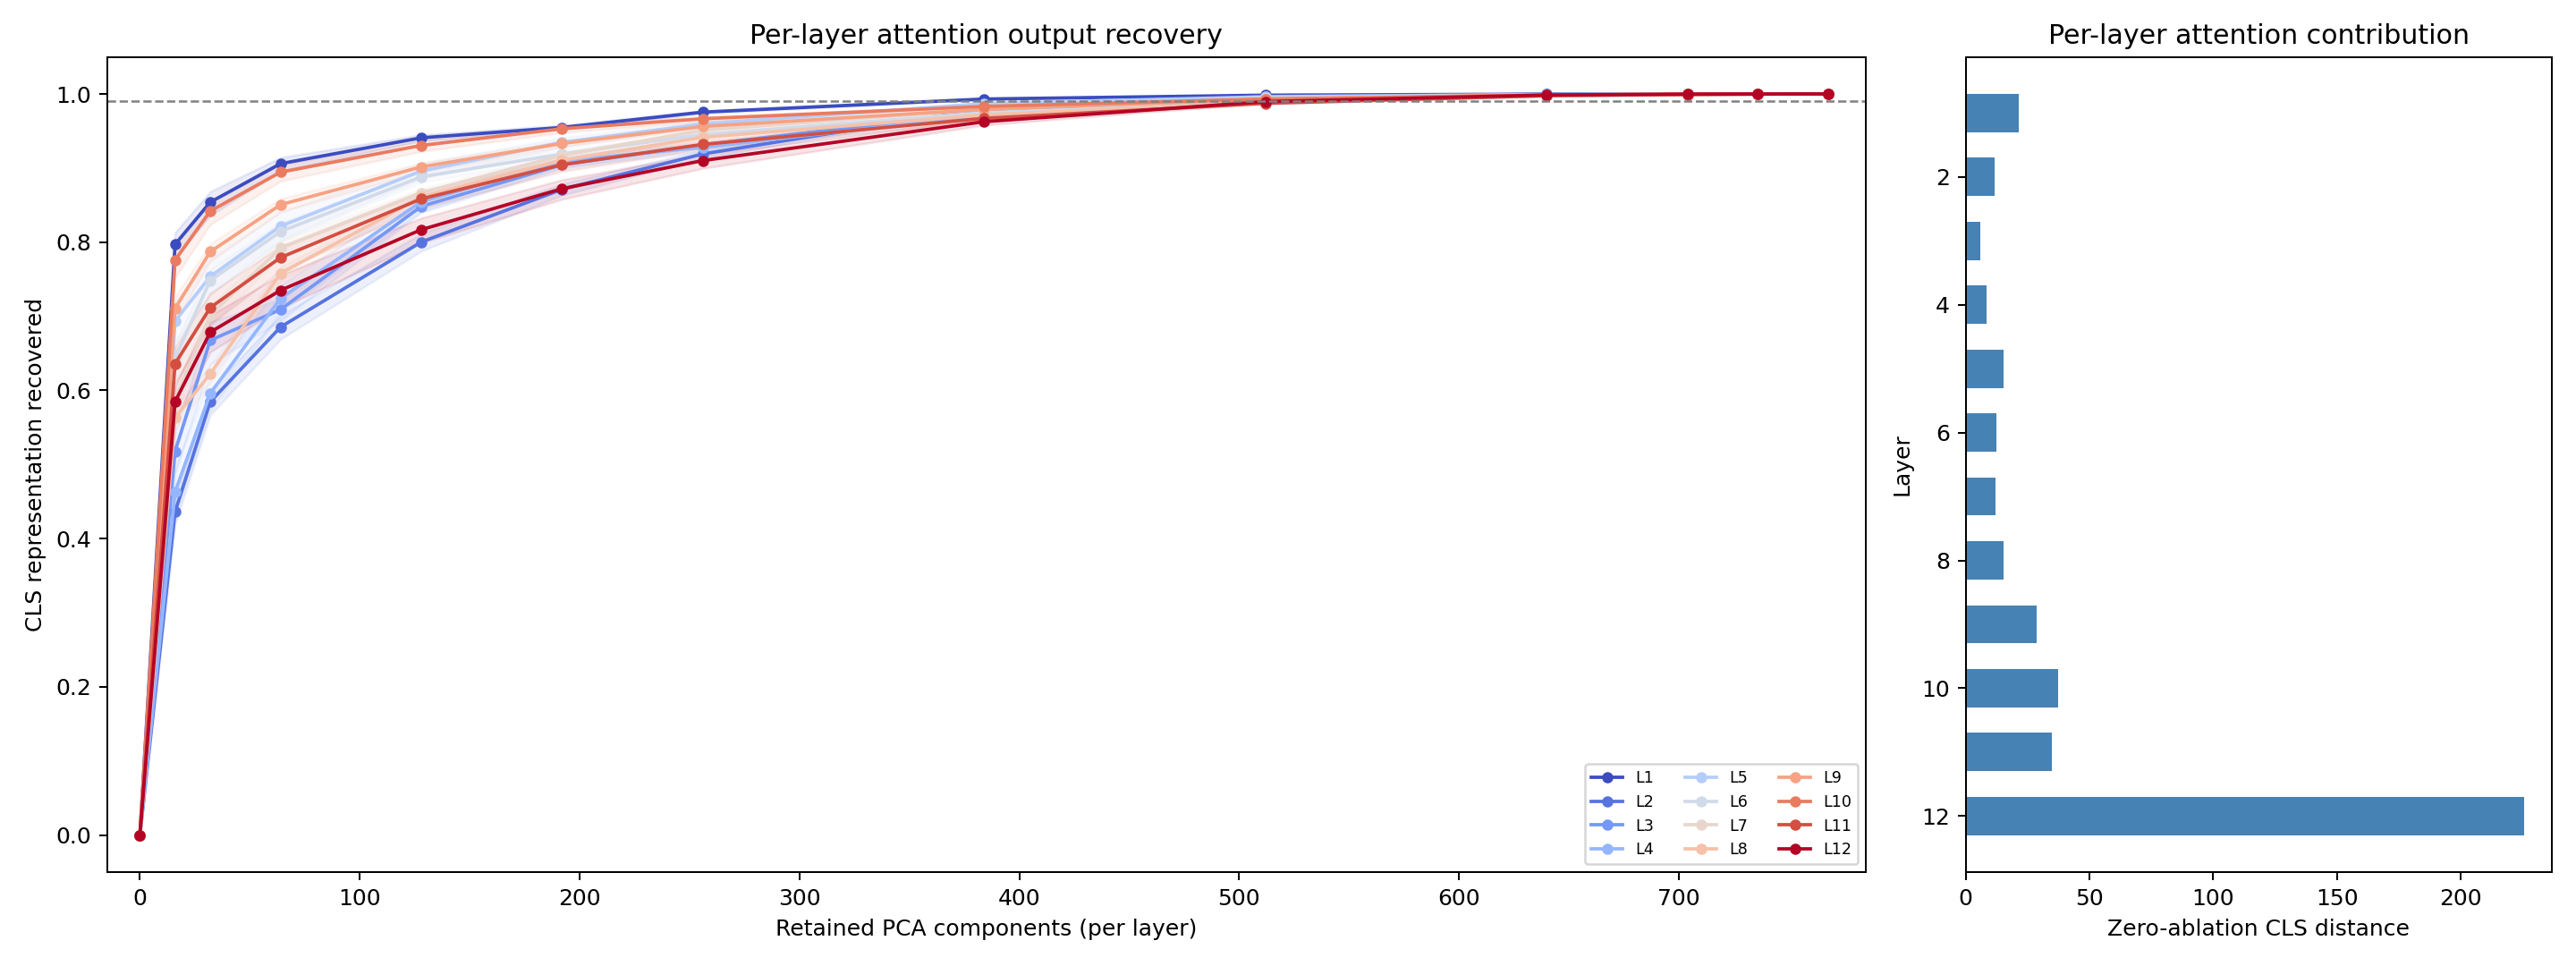

In [10]:
# 10. 逐层 attention output CLS 表征恢复
# 对每一层的 attention output 做 SVD 投影消融, 测量 CLS pooled representation
# 与基线的 L2 距离变化; PCA 样本与评估研报按 report_id/text hash 隔离。
from IPython.display import Image

from src.activation_rank_loss_recovery import run_loss_recovery_stage

LOSS_RECOVERY_POLICY = ROOT / 'configs' / 'activation_rank_loss_recovery.yaml'
loss_recovery_dir = run_loss_recovery_stage(config, LOSS_RECOVERY_POLICY)

loss_recovery_manifest = json.loads(
    (loss_recovery_dir / 'manifest.json').read_text(encoding='utf-8')
)
loss_recovery_summary = pd.read_parquet(loss_recovery_dir / 'site_summary.parquet')
loss_recovery_metrics = pd.read_parquet(
    loss_recovery_dir / 'loss_recovery_metrics.parquet'
)

display({
    'output': str(loss_recovery_dir),
    'loss_semantics': loss_recovery_manifest['loss_semantics'],
    'intervention_scope': loss_recovery_manifest['intervention_scope'],
    'layers': loss_recovery_manifest['layers'],
    'kinds': loss_recovery_manifest['kinds'],
    'evaluation_reports': loss_recovery_manifest['evaluation_reports'],
    'batch_size': loss_recovery_manifest['batch_size'],
    'pca_sample_report_overlap': loss_recovery_manifest['pca_sample_report_overlap'],
    'pca_sample_text_hash_overlap': loss_recovery_manifest['pca_sample_text_hash_overlap'],
})
display(loss_recovery_summary)
display(
    loss_recovery_metrics.loc[
        loss_recovery_metrics['n_components'].isin([0, 64, 128, 256, 384, 512, 768]),
        [
            'site', 'layer', 'n_components', 'distance_zero',
            'distance_projected', 'status', 'recovery_fraction',
            'recovery_ci_lower', 'recovery_ci_upper',
        ],
    ]
)
display(Image(filename=str(loss_recovery_dir / 'loss_recovery.png')))

In [11]:
# 11. 消融实验：所有层同时消融 — 排除"后层修复前层"假说
# 方案1: 所有12层同时消融, 统一 K = max(各层单层99%恢复所需K)
# 方案2: 所有12层同时消融, 扫描K网格, 画全层恢复曲线 vs 单层曲线
from contextlib import ExitStack
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.activation_rank_loss_recovery import (
    _load_candidate, _tokenize_evaluation, resolve_projection_module,
    SingleSiteProjection, select_disjoint_evaluation_reports,
    load_loss_recovery_policy,
)
from src.activation_rank import _model_paths, _mapping, _read_report_texts, _run_directory

# --- 从 cell 10 结果读取各层 K_99 ---
k99_per_layer = loss_recovery_summary.set_index('layer')['n_sustained_recovery'].dropna().astype(int).to_dict()
k_unified = max(k99_per_layer.values())
print('各层单层 99% 恢复所需 K:')
for l in sorted(k99_per_layer):
    print(f'  Layer {l:2d}: K_99 = {k99_per_layer[l]}')
print(f'\n方案1 统一 K = max(K_99) = {k_unified}')

# --- 加载模型 + 评估数据 (与 cell 10 一致) ---
run_dir = _run_directory(config)
base, checkpoint = _model_paths(config)
device = str(_mapping(config, 'model').get('device', 'cuda:1'))
pilot_manifest = json.loads((run_dir / 'pilot' / 'manifest.json').read_text(encoding='utf-8'))
dtype_name = pilot_manifest['selected_compute_dtype']
candidate, tokenizer = _load_candidate(base=base, checkpoint=checkpoint, device=device, dtype_name=dtype_name)

policy = load_loss_recovery_policy(ROOT / 'configs' / 'activation_rank_loss_recovery.yaml')
reports = _read_report_texts(config)
rank_sample = pd.read_parquet(run_dir / 'sample' / 'sample_manifest.parquet')
selected = select_disjoint_evaluation_reports(
    reports, rank_sample,
    report_count=int(policy['evaluation']['report_count']),
    order_seed=str(policy['evaluation']['order_seed']),
)
encoded = _tokenize_evaluation(tokenizer, selected, int(_mapping(config, 'model').get('max_length', 512)))

# SVD 基 (12 层各有自己的主成分矩阵)
sub = np.load(run_dir / 'analysis' / 'subspaces.npz', allow_pickle=False)
all_layers = list(range(1, 13))
bases = {f'attention_output_{l:02d}': sub[f'token_natural_filtered__attention_output_{l:02d}__eigenvectors'] for l in all_layers}
modules = [(l, resolve_projection_module(candidate.bert, f'attention_output_{l:02d}')) for l in all_layers]

# 基线 CLS
baseline_parts = []
with torch.inference_mode():
    for start in range(0, len(selected), 256):
        stop = min(start + 256, len(selected))
        inputs = {k: v[start:stop].pin_memory().to(device, non_blocking=True) for k, v in encoded.items()}
        out = candidate(**inputs)
        baseline_parts.append(out.pooled_feature.float().cpu())
baseline_cls = torch.cat(baseline_parts, dim=0)

def all_layer_distance(k):
    """同时消融所有12层 attention output 到 k 维, 返回平均 CLS L2 距离."""
    with ExitStack() as stack:
        if k < 768:
            for layer, module in modules:
                site = f'attention_output_{layer:02d}'
                stack.enter_context(SingleSiteProjection(module, bases[site], k))
        with torch.inference_mode():
            parts = []
            for start in range(0, len(selected), 256):
                stop = min(start + 256, len(selected))
                inputs = {key: v[start:stop].pin_memory().to(device, non_blocking=True) for key, v in encoded.items()}
                out = candidate(**inputs)
                parts.append(out.pooled_feature.float().cpu())
    modified_cls = torch.cat(parts, dim=0)
    distances = ((modified_cls - baseline_cls) ** 2).sum(dim=1)
    return float(distances.mean().item())

# 零消融基准 (所有层同时清零)
dist_zero_all = all_layer_distance(0)
print(f'\n所有层同时零消融 distance = {dist_zero_all:.4f}')

# --- 方案1: 统一 K = max(K_99) ---
dist_k_unified = all_layer_distance(k_unified)
recovery_scheme1 = 1 - dist_k_unified / dist_zero_all
print(f'\n=== 方案1: 所有层统一 K={k_unified} ===')
print(f'  distance = {dist_k_unified:.4f}, recovery = {recovery_scheme1:.1%}')

# --- 方案2: K 网格 ---
k_grid = [0, 16, 32, 64, 128, 192, 256, 384, 512, 640, 704, 736, 768]
scheme2 = []
for k in k_grid:
    d = all_layer_distance(k)
    r = 1 - d / dist_zero_all if dist_zero_all > 0 else float('nan')
    scheme2.append({'k': k, 'distance': round(d, 4), 'recovery': round(r, 4)})
    print(f'  K={k:3d}: distance={d:.4f}, recovery={r:.1%}')
scheme2_df = pd.DataFrame(scheme2)

# --- 画图 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左: 方案2 全层恢复曲线
ax1.plot(scheme2_df['k'], scheme2_df['recovery'], 'o-', linewidth=2, markersize=6, color='darkred', label='All 12 layers simultaneous')
ax1.axhline(0.99, color='gray', linestyle='--', alpha=0.5, label='99% recovered')
ax1.axvline(k_unified, color='red', linestyle=':', alpha=0.7, label=f'K_unified={k_unified}')
# 叠加各单层曲线做对比
colors = plt.cm.coolwarm(np.linspace(0, 1, 12))
for layer in all_layers:
    single = loss_recovery_metrics[loss_recovery_metrics['layer'] == layer].sort_values('n_components')
    ax1.plot(single['n_components'], single['recovery_fraction'], '-', color=colors[layer-1], alpha=0.2, linewidth=0.8)
ax1.set_xlabel('K (components per layer)')
ax1.set_ylabel('CLS representation recovered')
ax1.set_title('Scheme 2: All-layer simultaneous vs single-layer')
ax1.legend(fontsize=9)
ax1.set_ylim(-0.05, 1.05)

# 右: 方案1 对比柱状图 (在 K=K_unified 处)
single_at_k = loss_recovery_metrics[
    loss_recovery_metrics['n_components'] == k_unified
][['layer', 'recovery_fraction']].sort_values('layer')
ax2.bar(single_at_k['layer'], single_at_k['recovery_fraction'], alpha=0.5, color='steelblue', label='Single-layer ablation')
ax2.bar([13], [recovery_scheme1], alpha=0.7, color='darkred', label='All 12 layers simultaneous')
ax2.axhline(0.99, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Layer (13 = all simultaneous)')
ax2.set_ylabel(f'Recovery at K={k_unified}')
ax2.set_title(f'Scheme 1: Single vs All-layer at K={k_unified}')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

display(scheme2_df)

各层单层 99% 恢复所需 K:
  Layer  1: K_99 = 384
  Layer  2: K_99 = 512
  Layer  3: K_99 = 512
  Layer  4: K_99 = 512
  Layer  5: K_99 = 512
  Layer  6: K_99 = 640
  Layer  7: K_99 = 512
  Layer  8: K_99 = 640
  Layer  9: K_99 = 512
  Layer 10: K_99 = 512
  Layer 11: K_99 = 640
  Layer 12: K_99 = 640

方案1 统一 K = max(K_99) = 640


/home/intern_fjq_2026/miniconda3/envs/nlp_fjq/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


FileNotFoundError: 研报文本不存在: /home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/report_labels/reports.parquet

{'output': '/home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/checkpoint_activation_rank/runs/financial_reports_v2/extensions/attention_subspace_coverage_v1',
 'scope': 'descriptive_attention_write_space_geometry',
 'k_grid': [64, 128, 256, 384, 512, 640],
 'primary_k': 256,
 'layers': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 'random_overlap_formula': 'K / 768',
 'labels_or_returns_loaded': False}

,orthogonal_error,symmetry_error,projector_idempotency_error,trace_error,orthogonal_passed,symmetry_passed,projector_passed,trace_passed,k
0,2.160805e-08,0.0,4.711217e-09,2.911361e-08,True,True,True,True,64
1,2.160805e-08,0.0,6.009816e-09,1.197242e-08,True,True,True,True,128
2,2.160805e-08,0.0,6.313512e-09,9.028895e-09,True,True,True,True,256
3,2.160805e-08,0.0,7.669359e-09,1.129234e-08,True,True,True,True,384
4,2.160805e-08,0.0,8.245641e-09,1.499620e-08,True,True,True,True,512
5,2.160805e-08,0.0,8.527234e-09,2.425497e-08,True,True,True,True,640


,effective_coverage_rank,directions_coverage_below_005,directions_coverage_below_010,directions_coverage_above_050,directions_coverage_above_090,coverage_eigenvalue_min,coverage_eigenvalue_max,coverage_eigenvalue_mean,k,prefix_layers
0,349.51,449,559,9,0,0.000000,0.571241,0.083333,64,12
1,499.21,229,369,48,0,0.002166,0.677724,0.166667,128,12
2,634.98,1,86,185,0,0.008507,0.799443,0.333333,256,12
3,699.92,1,1,380,0,0.018983,0.886857,0.500000,384,12
4,736.39,1,1,595,67,0.037494,0.945844,0.666667,512,12
5,757.26,0,1,759,320,0.094441,0.989951,0.833333,640,12


,layer_i,layer_j,layer_distance,overlap,random_overlap_baseline,excess_overlap
418,11,11,0,1.000000,0.333333,0.666667
379,8,8,0,1.000000,0.333333,0.666667
314,3,3,0,1.000000,0.333333,0.666667
431,12,12,0,1.000000,0.333333,0.666667
327,4,4,0,1.000000,0.333333,0.666667
353,6,6,0,1.000000,0.333333,0.666667
340,5,5,0,1.000000,0.333333,0.666667
392,9,9,0,1.000000,0.333333,0.666667
405,10,10,0,1.000000,0.333333,0.666667
288,1,1,0,1.000000,0.333333,0.666667


,k,prefix_layers,effective_coverage_rank,directions_coverage_below_005,directions_coverage_above_050
0,64,1,64.00,704,64
1,64,2,102.53,645,64
2,64,3,134.82,604,58
3,64,4,158.70,580,50
4,64,5,191.87,553,44
...,...,...,...,...,...
67,640,8,751.99,0,728
68,640,9,753.23,0,735
69,640,10,754.37,0,742
70,640,11,755.80,0,750


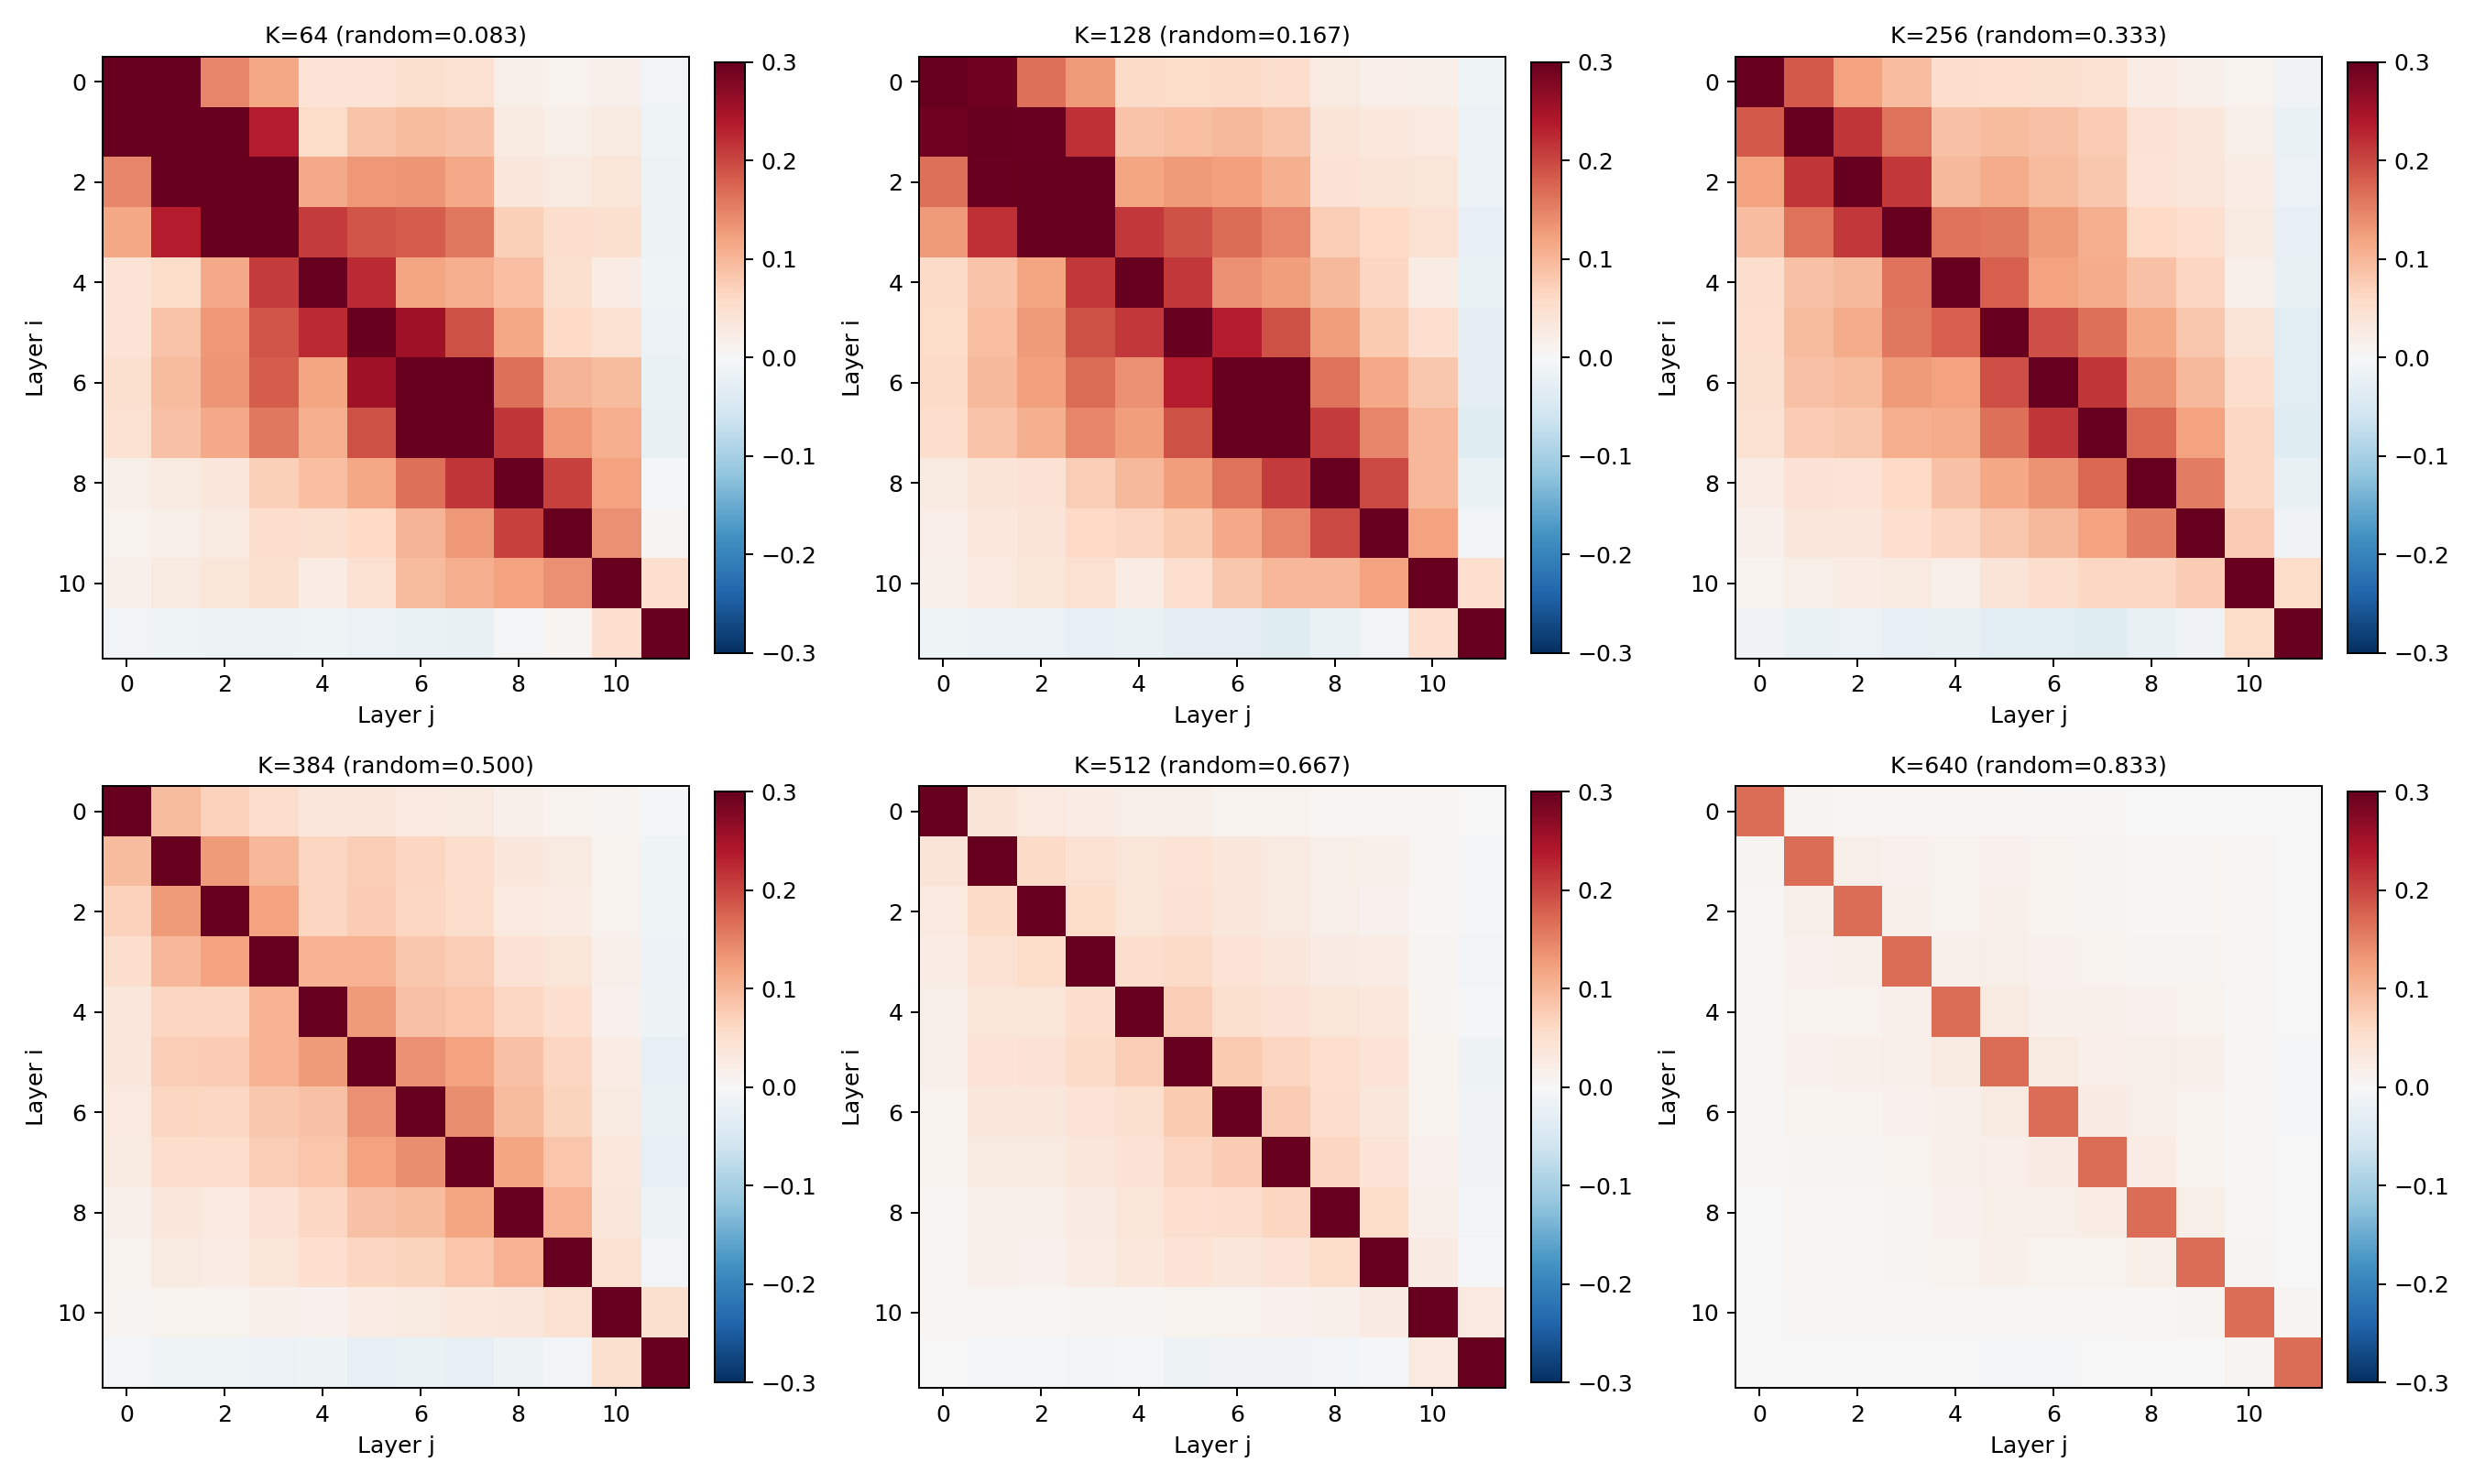

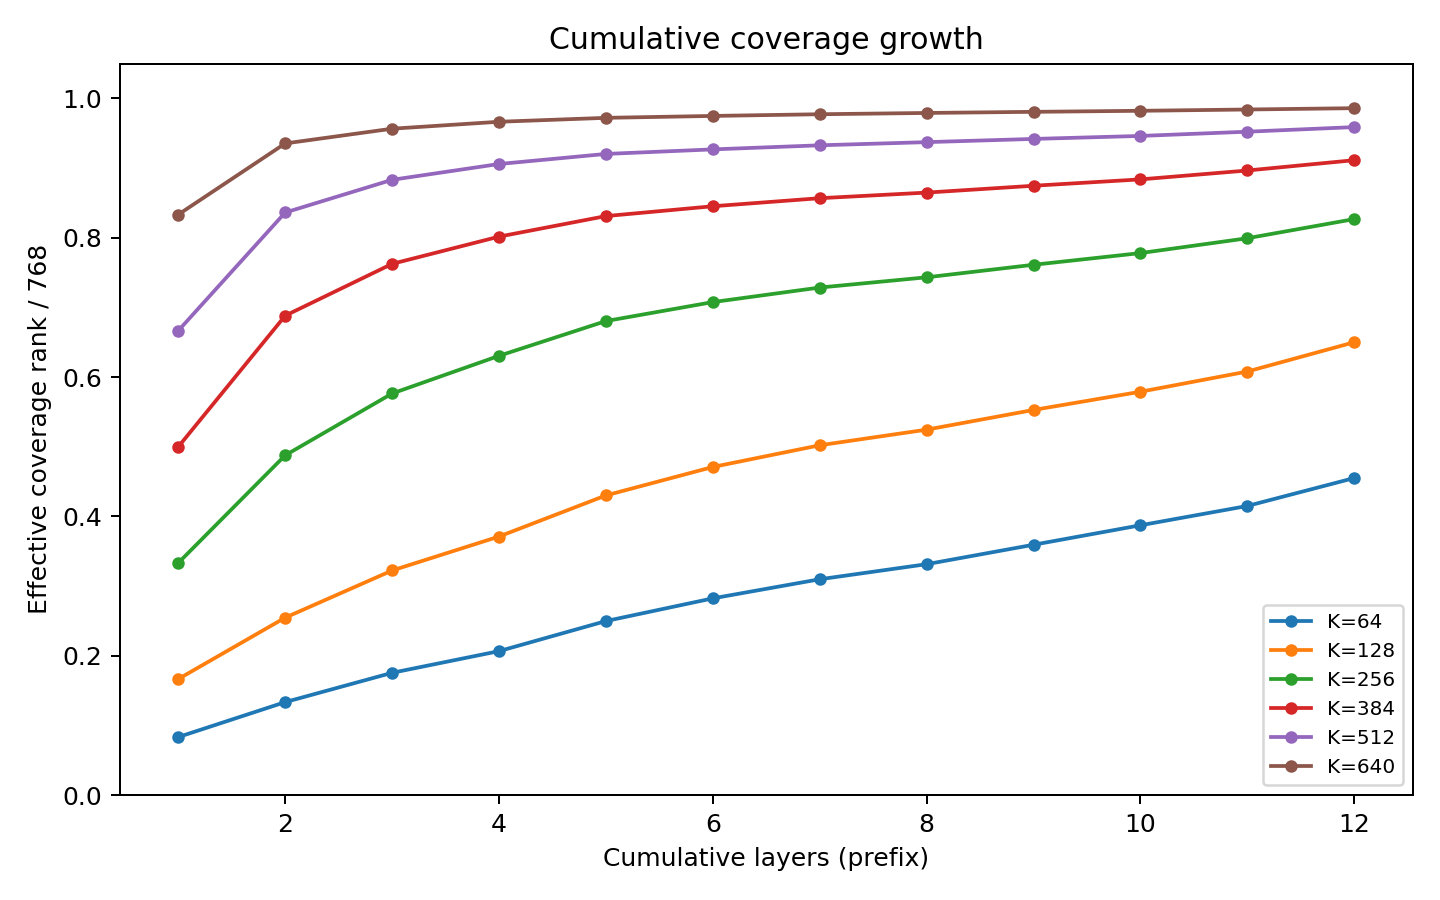

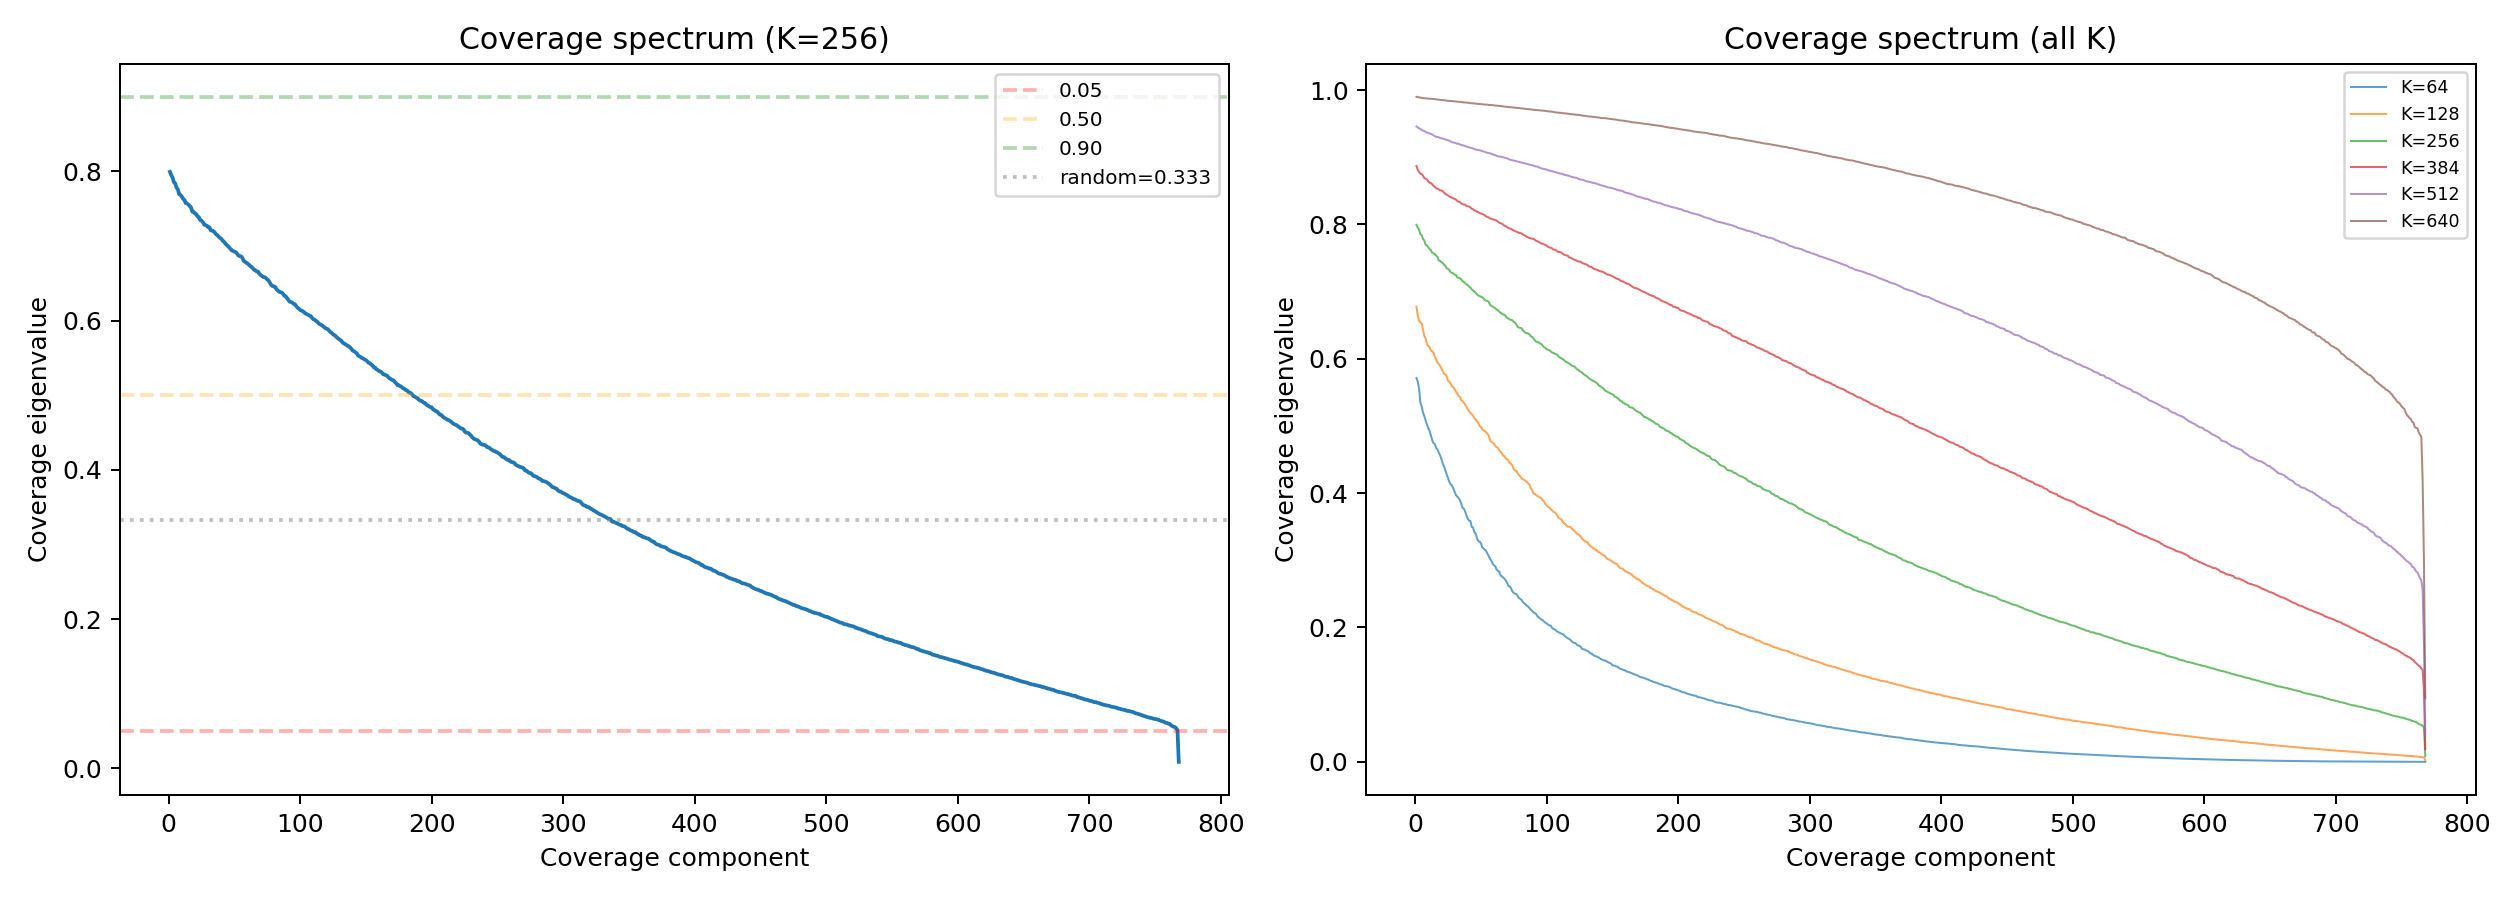

In [12]:
# 12. Attention output 写入子空间覆盖分析
# 纯线性代数: 各层 top-K 子空间的重合度、累计覆盖谱、低覆盖方向
# 不加载模型, 不读取标签, 仅复用上游 SVD 结果
from IPython.display import Image

from src.activation_subspace_coverage import run_coverage_stage

COVERAGE_POLICY = ROOT / 'configs' / 'activation_subspace_coverage.yaml'
coverage_dir = run_coverage_stage(config, COVERAGE_POLICY)

coverage_manifest = json.loads(
    (coverage_dir / 'manifest.json').read_text(encoding='utf-8')
)
pairwise_df = pd.read_parquet(coverage_dir / 'pairwise_overlap.parquet')
cumulative_df = pd.read_parquet(coverage_dir / 'cumulative_coverage.parquet')
eigvals_df = pd.read_parquet(coverage_dir / 'coverage_eigenvalues.parquet')
summary_df = pd.read_parquet(coverage_dir / 'coverage_summary.parquet')
invariants_df = pd.read_parquet(coverage_dir / 'numerical_invariants.parquet')

display({
    'output': str(coverage_dir),
    'scope': coverage_manifest['scope'],
    'k_grid': coverage_manifest['k_grid'],
    'primary_k': coverage_manifest['primary_k'],
    'layers': coverage_manifest['layers'],
    'random_overlap_formula': coverage_manifest['random_overlap_formula'],
    'labels_or_returns_loaded': coverage_manifest['labels_or_returns_loaded'],
})

# 数值不变量
display(invariants_df)

# 各 K 的 coverage summary
display(summary_df)

# 关键: K=256 (primary) 的 pairwise excess overlap
pk = summary_df['k'].min()  # primary_k from config
primary_k = coverage_manifest['primary_k']
excess_at_pk = pairwise_df[
    pairwise_df['k'] == primary_k
][['layer_i', 'layer_j', 'layer_distance', 'overlap',
    'random_overlap_baseline', 'excess_overlap']].sort_values(
    'excess_overlap', ascending=False)
display(excess_at_pk.head(20))

# 累计覆盖增长
display(cumulative_df[['k', 'prefix_layers', 'effective_coverage_rank',
    'directions_coverage_below_005', 'directions_coverage_above_050']])

# 三张图
display(Image(filename=str(coverage_dir / 'pairwise_overlap_heatmap.png')))
display(Image(filename=str(coverage_dir / 'cumulative_coverage.png')))
display(Image(filename=str(coverage_dir / 'coverage_spectrum.png')))